# K-means Clustering

**Autor:** Gil Brandon Garcia Contreras

**Fecha:** 5 de marzo de 2026

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as  px
import statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from kneed import KneeLocator

In [3]:
df = pd.read_csv('../../auto-mpg.csv')
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [4]:
df.isnull().sum()
df[~df['horsepower'].str.replace('.','',1).str.isnumeric()]['horsepower'].unique()
df['horsepower'] = pd.to_numeric(df['horsepower'].replace('?', np.nan), errors='coerce')

print(df['horsepower'].isnull().sum())

print(df['horsepower'].dtype)

6
float64


In [5]:
mean_hp = df['horsepower'].mean()

df['horsepower'] = df['horsepower'].fillna(mean_hp)

print(f"Nulos restantes: {df['horsepower'].isnull().sum()}")

Nulos restantes: 0


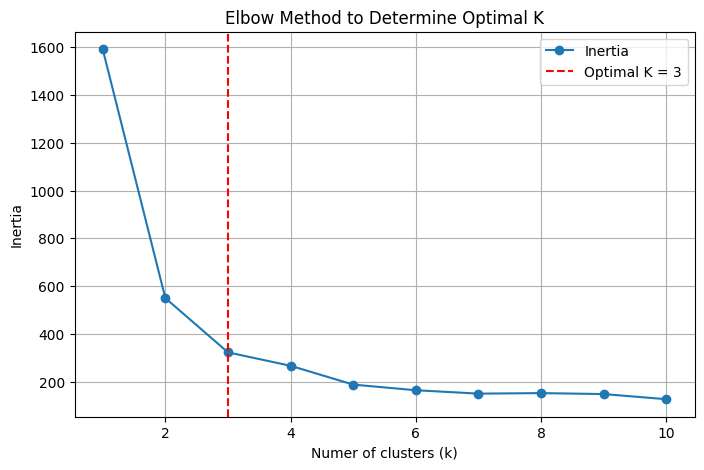

The optimal number of cluster (k) is: 3


In [17]:
features = ['mpg', 'displacement', 'horsepower', 'weight']
X = df[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

knee = KneeLocator(k_range, inertia, curve='convex', direction='decreasing')

optimal_k = knee.knee

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', label='Inertia')
plt.axvline(x=optimal_k, color='r', linestyle='--', label= f'Optimal K = {optimal_k}')
plt.title('Elbow Method to Determine Optimal K')
plt.xlabel('Numer of clusters (k)')
plt.ylabel('Inertia')
plt.legend()
plt.grid(True)
plt.show()

print(f"The optimal number of cluster (k) is: {optimal_k}")

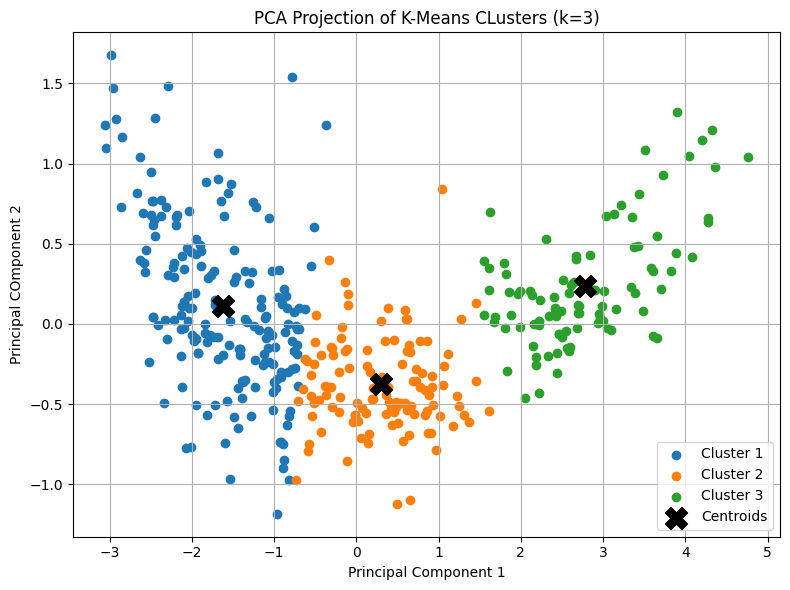

In [19]:
features = ['mpg', 'displacement', 'horsepower', 'weight']
X = df[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

k = optimal_k
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
for cluster_id in range(k):
    plt.scatter(
        X_pca[clusters == cluster_id, 0],
        X_pca[clusters == cluster_id, 1],
        label = f'Cluster {cluster_id + 1}'
    )

centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    s = 250, c='black', marker='X', label='Centroids'
)

plt.title('PCA Projection of K-Means CLusters (k=3)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal COmponent 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

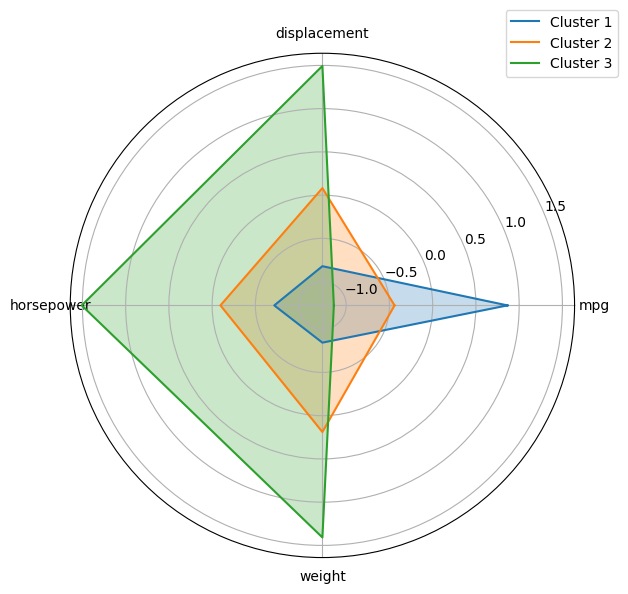

In [26]:
df['cluster'] = kmeans.fit_predict(X_scaled)

cluster_centers_scaled = kmeans.cluster_centers_

labels = features
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 6), subplot_kw=dict(polar=True))

for i in range(3):
    values = cluster_centers_scaled[i].tolist()
    values += values[:1]
    ax.plot(angles, values, label=f'Cluster {i+1}')
    ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))
plt.tight_layout()
plt.show()

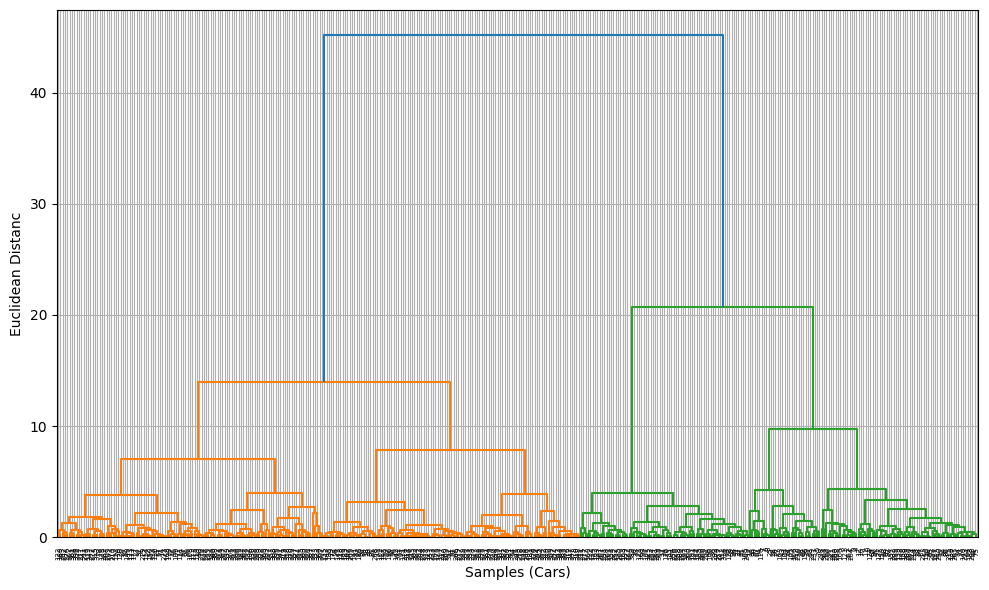

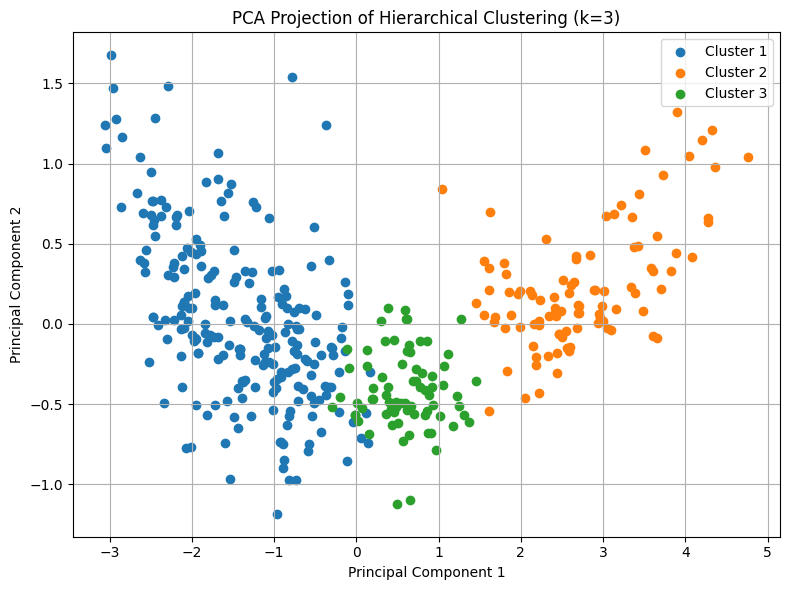

In [37]:
import scipy.cluster.hierarchy as sch
from  sklearn.cluster import AgglomerativeClustering

features = ['mpg', 'displacement', 'horsepower', 'weight']
X = df[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

plt.figure(figsize=(10, 6))
dendogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.xlabel('Samples (Cars)')
plt.ylabel('Euclidean Distanc')
plt.grid(True)
plt.tight_layout()
plt.show()



hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
df['cluster_hierarchical'] = hc.fit_predict(X_scaled)

pca=PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
for cluster_id in range(3):
    plt.scatter(
        X_pca[df['cluster_hierarchical'] == cluster_id, 0],
        X_pca[df['cluster_hierarchical'] == cluster_id, 1],
        label=f'Cluster {cluster_id + 1}'
    )

plt.title('PCA Projection of Hierarchical Clustering (k=3)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()